In [1]:
import sys
print(sys.version)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


In [2]:
!pip install tensorflow

C:\Users\praty\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9238 - loss: 0.2581 - val_accuracy: 0.9685 - val_loss: 0.1062
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9678 - loss: 0.1061 - val_accuracy: 0.9682 - val_loss: 0.1013
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9769 - loss: 0.0742 - val_accuracy: 0.9752 - val_loss: 0.0875
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9824 - loss: 0.0550 - val_accuracy: 0.9775 - val_loss: 0.0726
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9842 - loss: 0.0469 - val_accuracy: 0.9762 - val_loss: 0.0786
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9772 - loss: 0.0798
Test Accuracy: 0.9771999716758728
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


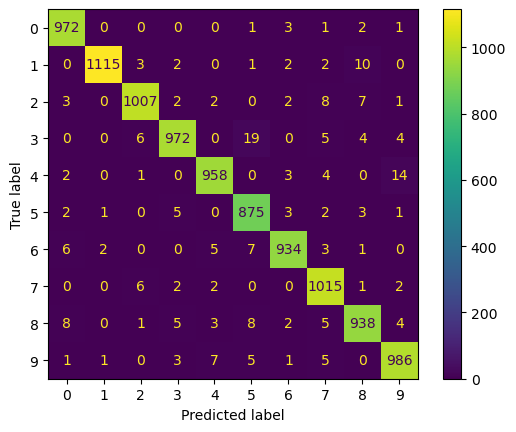

First 10 Misclassified Image IDs:
[233, 247, 259, 321, 340, 381, 445, 447, 495, 583]


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load and Preprocess Data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# 2. Build the DNN Architecture
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),

    # Hidden Layer 1
    layers.Dense(128, activation='relu'),

    # Hidden Layer 2
    layers.Dense(64, activation='relu'),

    # Output Layer
    layers.Dense(10, activation='softmax')
])

# 3. Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the Model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

# Predictions
y_pred = model.predict(x_test)
y_pred_classes = y_pred.argmax(axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

misclassified = []

for i in range(len(y_test)):
    if y_test[i] != y_pred_classes[i]:
        misclassified.append(i)

print("First 10 Misclassified Image IDs:")
print(misclassified[:10])

In [4]:
for idx in misclassified[:3]:
    print("Image ID:", idx)
    print("True Label:", y_test[idx])
    print("Predicted Label:", y_pred_classes[idx])
    print()

Image ID: 233
True Label: 8
Predicted Label: 3

Image ID: 247
True Label: 4
Predicted Label: 6

Image ID: 259
True Label: 6
Predicted Label: 0



In [5]:
y_pred_classes = y_pred.argmax(axis=1)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)

acc = accuracy_score(
    y_test,
    y_pred_classes
)

prec = precision_score(
    y_test,
    y_pred_classes,
    average='weighted'
)

rec = recall_score(
    y_test,
    y_pred_classes,
    average='weighted'
)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)

Accuracy : 0.9772
Precision: 0.9773205900046036
Recall   : 0.9772
